# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [4]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [10]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [ ]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Data testing

Let's test our implementation of `label_smoothing()` for the `EMNISTDataProvider` below:

In [ ]:
def label_smoothing(int_targets, num_classes, alpha=0.1):
        """Converts integer coded class target to 1 of K coded targets with label smoothing.

        Args:
        int_targets (ndarray): Array of integer coded class targets (i.e.
        where an integer from 0 to `num_classes` - 1 is used to
        indicate which is the correct class). This should be of shape
        (num_data,).
        alpha (float): Smoothing factor.

        Returns:
        Array of 1 of K coded targets with label smoothing i.e. an array of shape
        (num_data, num_classes)

        """
        
        smoothed_targets = np.full((int_targets.shape[0], num_classes), (alpha / (num_classes-1)))
        smoothed_targets[range(int_targets.shape[0]), int_targets] = 1 - alpha
        return smoothed_targets

In [ ]:

# Generate some test one-hot targets for label_smoothing
num_samples = 5
num_classes = 10
test_targets = np.array([np.random.randint(0, num_classes) for i in range(num_samples)])

print("Original test targets:")
print(test_targets)

# Apply label smoothing with a smoothing factor, e.g., 0.1
smoothed_test_targets = label_smoothing(test_targets, num_classes)

print("Smoothed test targets:")
print(smoothed_test_targets)


## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

In [ ]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 10
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [ ]:
# You can then check the plots like this
fig_1 # The training error plot

In [ ]:
fig_2 # The training accuracy plot

In [ ]:
grad_plot # The gradient flow plot

## Task 1: Problem Identification

### i) Varying number of hidden units.

Here we train various 1-hidden layer networks by using 32, 64, 128 ReLU units on the hidden layer. We then see how that changes the error and accuracy curves (i.e. model performance)

In [ ]:
%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim = 784, 47
hidden_dims = [32, 64, 128]

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

fig_error = plt.figure(figsize=(8,4))
fig_acc = plt.figure(figsize=(8,4))

stats_all_runs = {}

for i, hidden_dim in enumerate(hidden_dims):
    print(f"Training model with {hidden_dim} hidden units")
    model = MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
        ReluLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
    ])

    error = CrossEntropySoftmaxError()
    # Use a Adam learning rule
    learning_rule = AdamLearningRule(learning_rate=learning_rate)

    stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
    
    stats_all_runs[i] = stats


In [ ]:
# Plotting error figure
fig_all_errors = plt.figure(figsize=(8,4))
ax = fig_all_errors.add_subplot(111)

# First plot training errors for each number of units
for i, hidden_dim in enumerate(hidden_dims):
    stats = stats_all_runs[i]
    # Use the known column indices for error metrics
    train_error_idx = 0  # error(train) is first column
    
    ax.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, train_error_idx], 
            label=f'width {hidden_dim}(train)')
        
    
# Then validation errors
for i, hidden_dim in enumerate(hidden_dims):
    stats = stats_all_runs[i]
    # Use the known column indices for error metrics
    valid_error_idx = 2  # error(valid) is third column
    
    ax.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, valid_error_idx], linestyle='dashed' ,
            label=f'width {hidden_dim}(valid)', )
    

ax.legend(loc=0)
ax.set_xlabel('Epoch number')
ax.set_ylabel('Error')
fig_all_errors.tight_layout()
fig_all_errors.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/error_curves_width.png')

# Plotting acc figure
fig_all_accs = plt.figure(figsize=(8,4))
ax = fig_all_accs.add_subplot(111)

# First plot training accs for each number of units
for i, hidden_dim in enumerate(hidden_dims):
    stats = stats_all_runs[i]
    train_acc_idx = 1 
    
    ax.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, train_acc_idx], 
            label=f'width {hidden_dim}(train)')
        
    
# Then validation accs
for i, hidden_dim in enumerate(hidden_dims):
    stats = stats_all_runs[i]
    valid_acc_idx = 3  
    
    ax.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, valid_acc_idx], linestyle='dashed' ,
            label=f'width {hidden_dim}(valid)', )
    

ax.legend(loc=0)
ax.set_xlabel('Epoch number')
ax.set_ylabel('Accuracy')
fig_all_accs.tight_layout()
fig_all_accs.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/acc_curves_width.png')
    



In [53]:
print(stats_all_runs[0][-1])
print(stats_all_runs[1][-1])
print(stats_all_runs[2][-1])

[0.55829789 0.82318    0.69851478 0.78398734]
[0.35532359 0.87627    0.68229083 0.80721519]
[0.15644259 0.94062    0.9732564  0.80208861]


### ii) Varying number of layers

Here I will train various neural networks by using either 1, 2, 3 hidden layers with
128 ReLU hidden units per layer on EMNIST

In [6]:
# Helper to generate model with varying number of layers

def generate_layers(num_hidden_layers):
  layers = []

  # Add input layer
  layers.append(AffineLayer(input_dim, hidden_dim, weights_init, biases_init))

  # Add hidden layers
  for k in range(num_hidden_layers-1):
    layers.append(AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init)) # Affine layer
    layers.append(ReluLayer()) # ReLU layer
  
  # Add output layer
  layers.append(AffineLayer(hidden_dim, output_dim, weights_init, biases_init))
  return layers

In [8]:
generate_layers(3)

[AffineLayer(input_dim=784, output_dim=128),
 AffineLayer(input_dim=128, output_dim=128),
 ReluLayer,
 AffineLayer(input_dim=128, output_dim=128),
 ReluLayer,
 AffineLayer(input_dim=128, output_dim=47)]

In [11]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

Training model with 1 hidden layers


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: 1.6s to complete
    error(train)=1.18e+00, acc(train)=6.73e-01, error(valid)=1.20e+00, acc(valid)=6.69e-01
Epoch 50: 1.3s to complete
    error(train)=1.01e+00, acc(train)=7.19e-01, error(valid)=1.15e+00, acc(valid)=6.86e-01
Epoch 100: 1.3s to complete
    error(train)=9.90e-01, acc(train)=7.24e-01, error(valid)=1.16e+00, acc(valid)=6.83e-01


Training model with 2 hidden layers


  0%|          | 0/100 [00:00<?, ?it/s]

...

Training model with 3 hidden layers


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: 1.8s to complete
    error(train)=7.17e-01, acc(train)=7.74e-01, error(valid)=7.44e-01, acc(valid)=7.67e-01
Epoch 50: 1.9s to complete
    error(train)=2.09e-01, acc(train)=9.15e-01, error(valid)=8.45e-01, acc(valid)=8.18e-01
Epoch 100: 1.9s to complete
    error(train)=1.60e-01, acc(train)=9.35e-01, error(valid)=1.21e+00, acc(valid)=8.17e-01


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

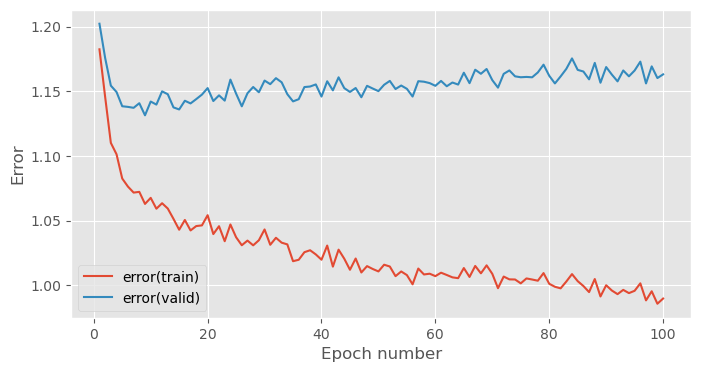

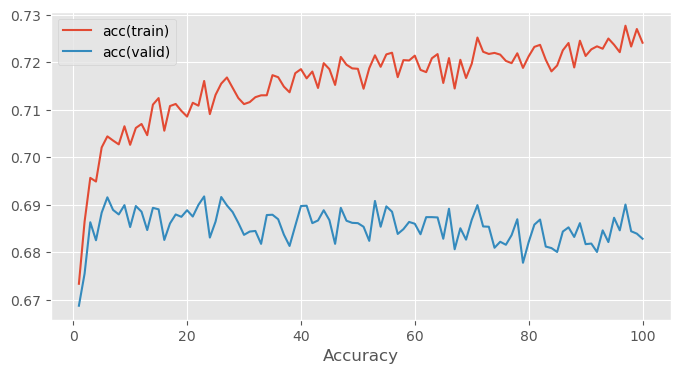

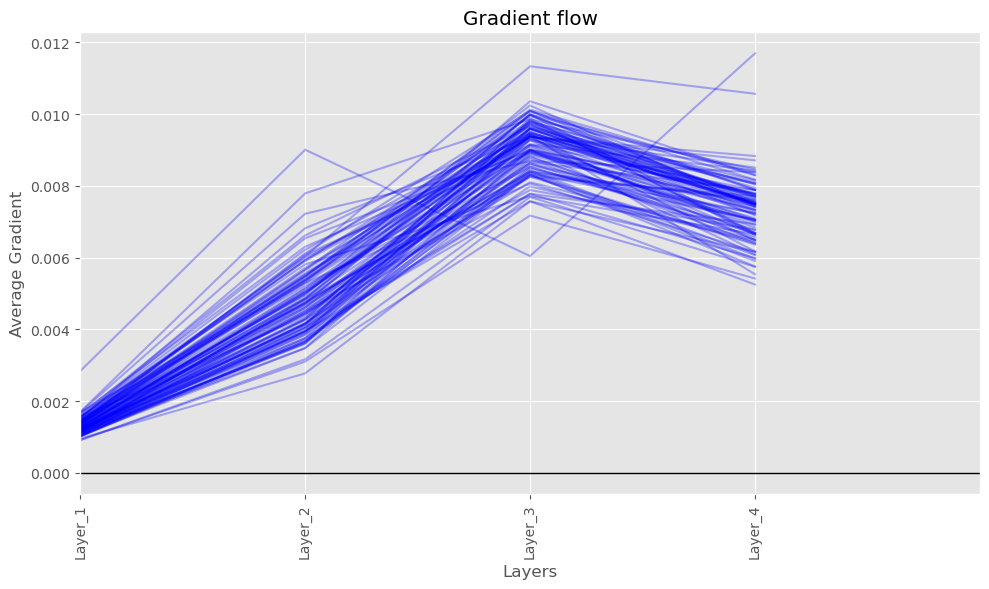

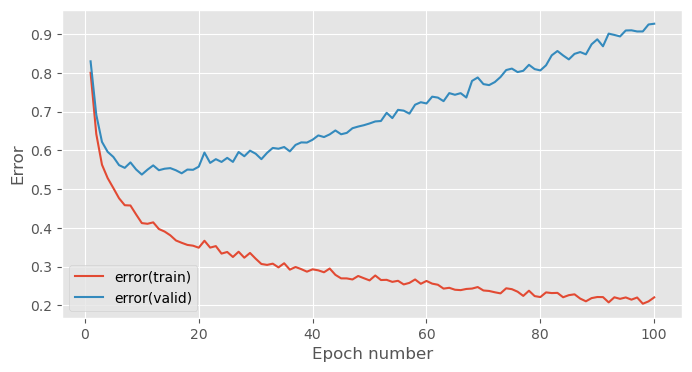

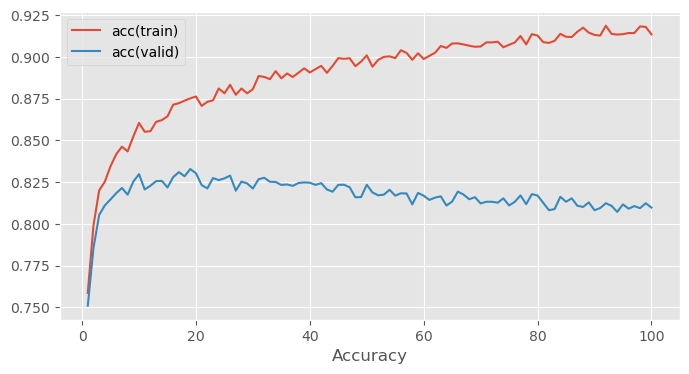

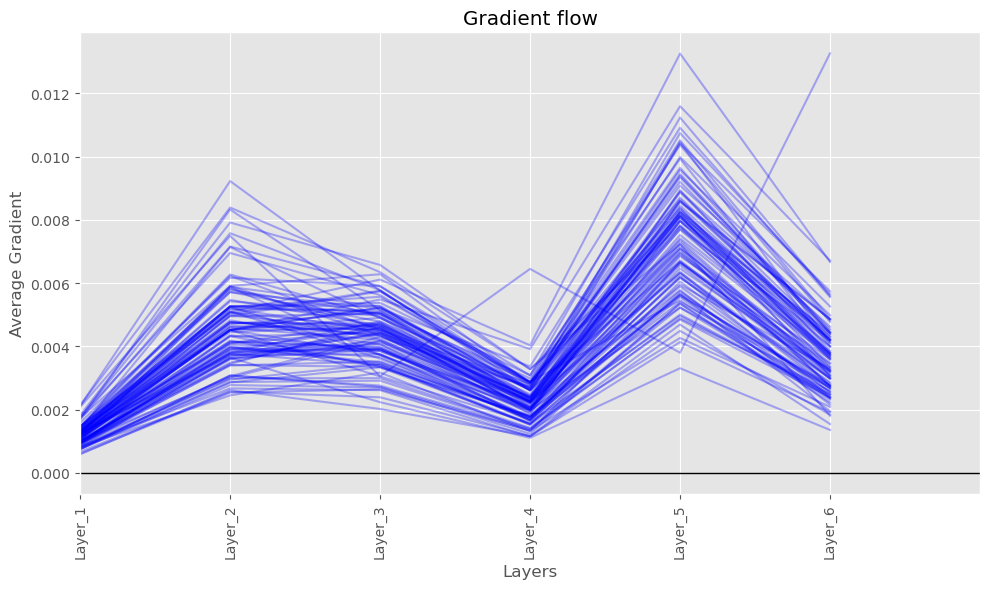

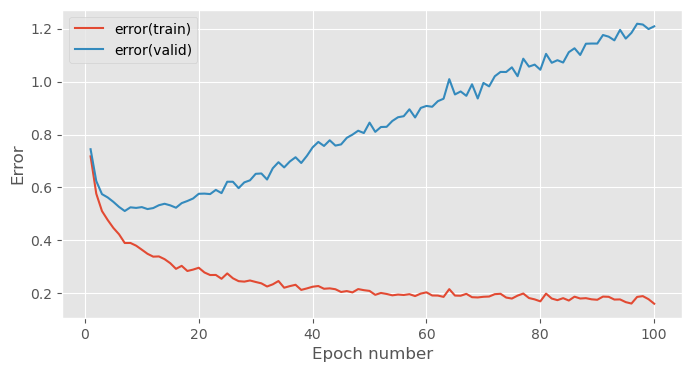

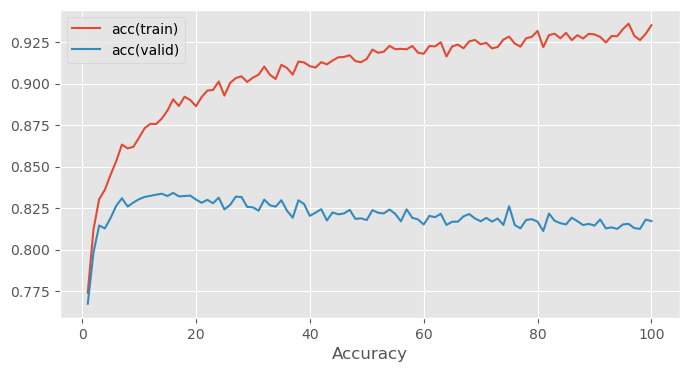

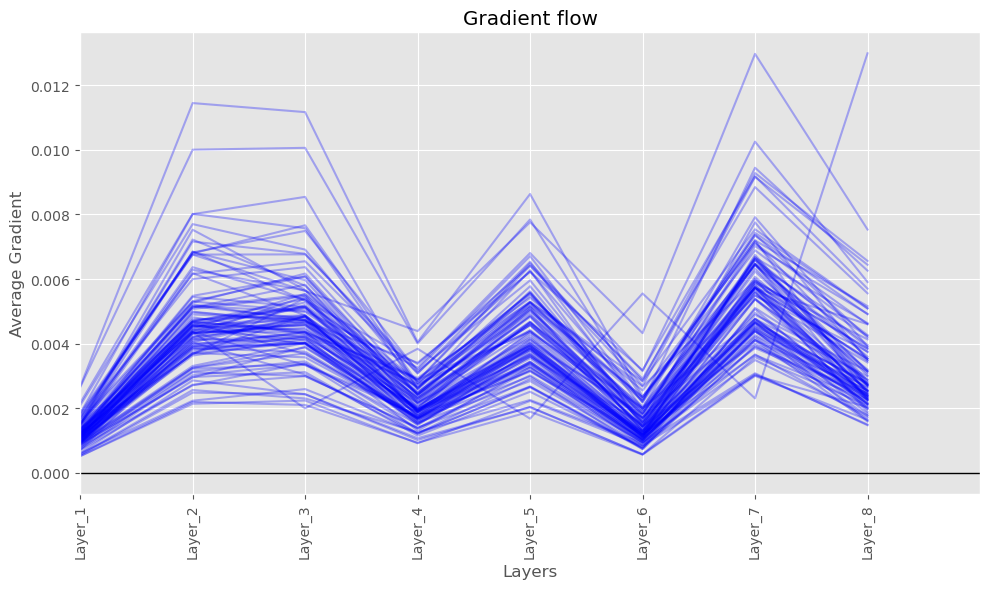

In [12]:
# Train model and get data from varying number of hidden layers

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Define number of hidden layers
num_hidden_layers = [1,2,3]

fig_error_height = plt.figure(figsize=(8,4))
fig_acc_height = plt.figure(figsize=(8,4))

stats_all_runs_height = {}

for i, num_hidden in enumerate(num_hidden_layers):
    print(f"Training model with {num_hidden} hidden layers")
    model = MultipleLayerModel(generate_layers(num_hidden))

    stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
    
    stats_all_runs_height[i] = stats


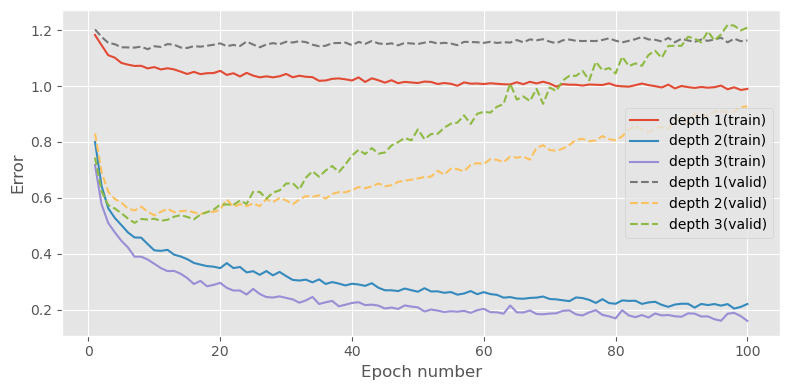

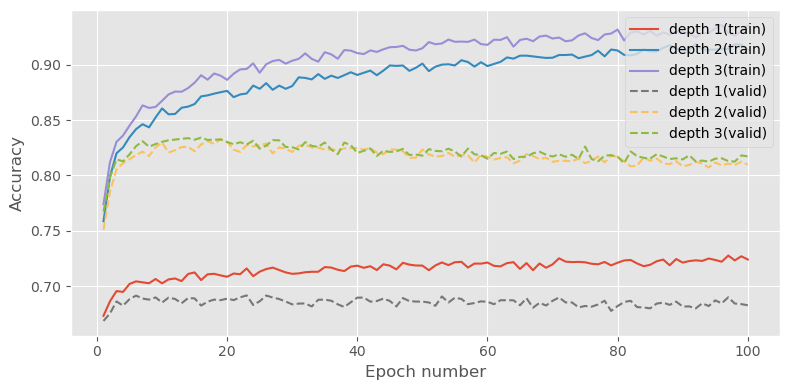

In [16]:
# Plotting error figure
fig_all_errors_height = plt.figure(figsize=(8,4))
ax_height = fig_all_errors_height.add_subplot(111)

# First plot training errors for each number of units
for i, num_hidden in enumerate(num_hidden_layers):
    stats = stats_all_runs_height[i]
    # Use the known column indices for error metrics
    train_error_idx = 0  # error(train) is first column
    
    ax_height.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, train_error_idx], 
            label=f'depth {num_hidden}(train)')
        
    
# Then validation errors
for i, num_hidden in enumerate(num_hidden_layers):
    stats = stats_all_runs_height[i]
    # Use the known column indices for error metrics
    valid_error_idx = 2  # error(valid) is third column
    
    ax_height.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, valid_error_idx], linestyle='dashed' ,
            label=f'depth {num_hidden}(valid)', )
    

ax_height.legend(loc=0)
ax_height.set_xlabel('Epoch number')
ax_height.set_ylabel('Error')
fig_all_errors_height.tight_layout()
fig_all_errors_height.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/error_curves_height.png')

# Plotting acc figure
fig_all_accs_height = plt.figure(figsize=(8,4))
ax_height = fig_all_accs_height.add_subplot(111)

# First plot training accs for each number of units
for i, num_hidden in enumerate(num_hidden_layers):
    stats = stats_all_runs_height[i]
    train_acc_idx = 1 
    
    ax_height.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, train_acc_idx], 
            label=f'depth {num_hidden}(train)')
        
    
# Then validation accs
for i, num_hidden in enumerate(num_hidden_layers):
    stats = stats_all_runs_height[i]
    valid_acc_idx = 3  
    
    ax_height.plot(np.arange(1, stats.shape[0]) * stats_interval, 
            stats[1:, valid_acc_idx], linestyle='dashed' ,
            label=f'depth {num_hidden}(valid)', )
    

ax_height.legend(loc=0)
ax_height.set_xlabel('Epoch number')
ax_height.set_ylabel('Accuracy')
fig_all_accs_height.tight_layout()
fig_all_accs_height.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/acc_curves_height.png')
    



Getting stats form last three runs:

In [18]:
print('error(train)', 'acc(train)', 'error(valid)', 'acc(valid)')
print(stats_all_runs_height[0][-1])
print(stats_all_runs_height[1][-1])
print(stats_all_runs_height[2][-1])

error(train) acc(train) error(valid) acc(valid)
[0.98983351 0.72417    1.16311935 0.6828481 ]
[0.22075003 0.91356    0.92699796 0.80981013]
[0.16022454 0.93508    1.20896947 0.81721519]
